In [9]:
import ipywidgets as widgets
widgets.IntSlider()
from tqdm.auto import tqdm
for _ in tqdm(range(100)):
    pass


  0%|          | 0/100 [00:00<?, ?it/s]

In [15]:
import torch

print("torch:", torch.__version__)

cuda_available = torch.cuda.is_available()
print("CUDA available:", cuda_available)

if cuda_available:
    print("GPU:", torch.cuda.get_device_name(0))
    print("Capability:", torch.cuda.get_device_capability(0))

    # quick compute test
    x = torch.randn(2048, 2048, device="cuda")
    y = x @ x
    torch.cuda.synchronize()
    print("GPU compute test: ok")

torch: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 5060 Ti
Capability: (12, 0)
GPU compute test: ok


In [12]:
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
import cv2

processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten")
model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-handwritten")
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

C:\Users\Carl\anaconda3\envs\OCR-ml\lib\site-packages\huggingface_hub\file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-base-handwritten and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


VisionEncoderDecoderModel(
  (encoder): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=False)
              (key): Linear(in_features=768, out_features=768, bias=False)
              (value): Linear(in_features=768, out_features=768, bias=False)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_fea

In [2]:
from PIL import Image
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

IMAGE_DIR = r"C:\Users\Carl\Python\Projects\OCR\data\testimages"

image_files = sorted([
    f for f in os.listdir(IMAGE_DIR)
    if f.lower().endswith((".png", ".jpg", ".jpeg", ".tif", ".tiff"))
])

print(len(image_files))
print(image_files[:5])

def show(img, title=""):
    plt.figure(figsize=(6,8))
    plt.title(title)

    if img.ndim == 2:  # grayscale or binary
        plt.imshow(img, cmap="gray")
    else:  # color image (assume BGR)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

    plt.axis("off")
    plt.show()

def grayscale_bgr(img_bgr):
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)


27
['a01-000u.png', 'a01-003u.png', 'a01-007u.png', 'a01-011u.png', 'a01-014u.png']


LOADING: C:\Users\Carl\Python\Projects\OCR\data\testimages\a01-003u.png
NONE?: False
SHAPE: (3542, 2479, 3)
SUM: 2023857770


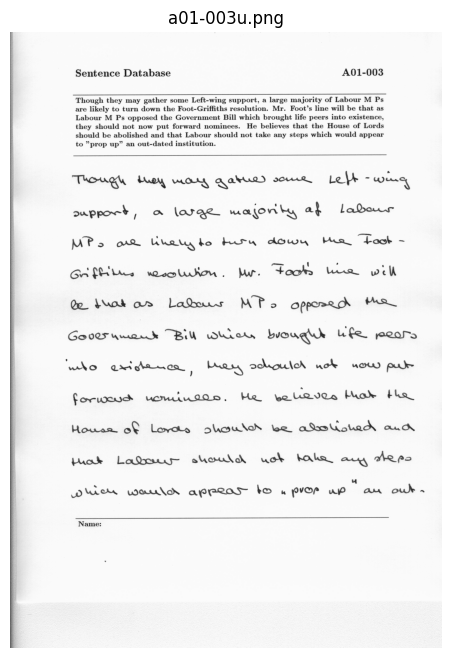

In [5]:
# Load and show one image
img_path = os.path.join(IMAGE_DIR, image_files[1])
img_bgr = cv2.imread(img_path)

print("LOADING:", img_path)
print("NONE?:", img_bgr is None)
print("SHAPE:", img_bgr.shape)
print("SUM:", int(img_bgr.sum()))

show(img_bgr, image_files[1])

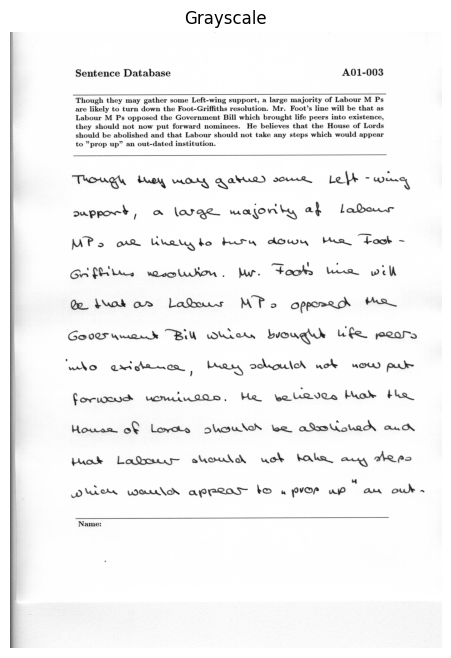

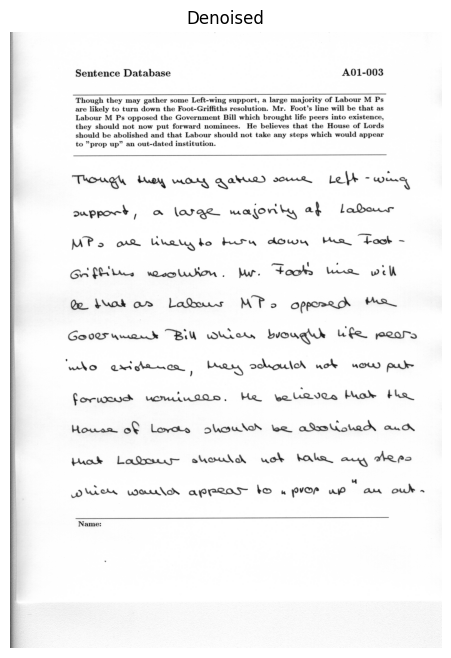

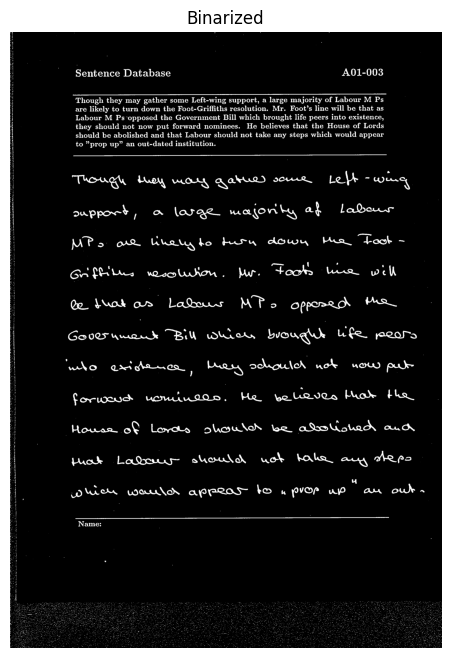

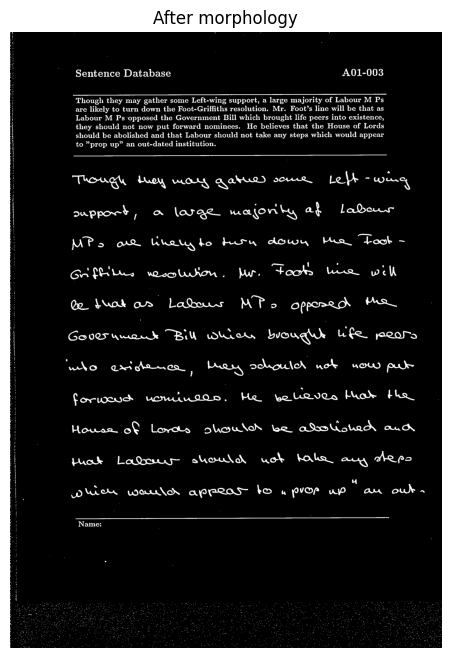

In [6]:
#Grayascale, Bin, denoise = Morph

# Grayscale
gray = grayscale_bgr(img_bgr)
show(gray, "Grayscale")

# Denoising
gray_dn = cv2.GaussianBlur(gray, (3,3), 0)
show(gray_dn, "Denoised")

# Binarization (Turn grayscale into black/white)
bw = cv2.adaptiveThreshold(
    gray_dn, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    31, 10
)
show(bw, "Binarized")

# Morphology (shape cleanup)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2,2))
bw_clean = cv2.morphologyEx(bw, cv2.MORPH_OPEN, kernel, iterations=1)
show(bw_clean, "After morphology")

ROI SUM: 3272762943


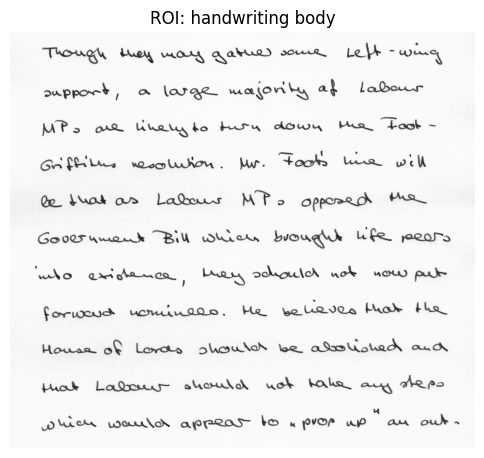

In [7]:
#Cropping
def crop_rois(img_bgr):
    h, w = img_bgr.shape[:2]
    #  Handwriting block (main body)
    roi_hand = img_bgr[int(0.21*h):int(0.78*h), int(0.08*w):int(0.99*w)]

    return roi_hand

img_bgr = cv2.imread(img_path)
roi_hand = crop_rois(img_bgr)
print("ROI SUM:", int(roi_hand.sum()))

show(roi_hand, "ROI: handwriting body")



USING: C:\Users\Carl\Python\Projects\OCR\data\testimages\a01-003u.png
IMG SUM: 2023857770
ROI_HAND SUM: 3272762943


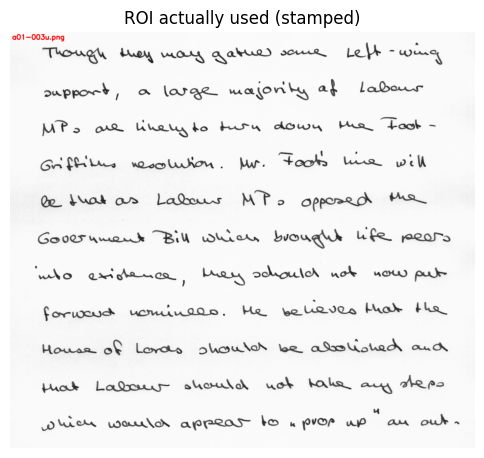

ROI_TIGHT SUM: 3272762943


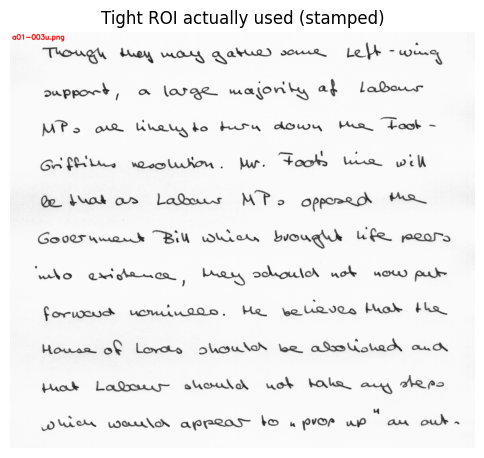

Num lines: 11


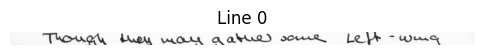

NameError: name 'trocr_ocr' is not defined

In [13]:
#Splitting lines OCR
idx = 1  # change this to test other images

img_path = os.path.join(IMAGE_DIR, image_files[idx])
img_bgr  = cv2.imread(img_path)

print("USING:", img_path)
print("IMG SUM:", int(img_bgr.sum()))

# --- crop handwriting ROI (your existing crop_rois returns only roi_hand) ---
roi_hand = crop_rois(img_bgr)
print("ROI_HAND SUM:", int(roi_hand.sum()))

tmp = roi_hand.copy()
cv2.putText(tmp, os.path.basename(img_path), (10, 40),
            cv2.FONT_HERSHEY_SIMPLEX, 1.1, (0,0,255), 3)
show(tmp, "ROI actually used (stamped)")

# --- tight crop (restricted band) ---
def tight_crop_to_ink(roi_bgr, pad=15, top_frac=0.21, bottom_frac=0.78):
    h_full, w_full = roi_bgr.shape[:2]

    y0_search = int(top_frac * h_full)
    y1_search = int(bottom_frac * h_full)
    if y1_search <= y0_search + 10:
        return roi_bgr  # safety

    roi_sub = roi_bgr[y0_search:y1_search, :]

    gray = cv2.cvtColor(roi_sub, cv2.COLOR_BGR2GRAY)
    bw = cv2.adaptiveThreshold(
        gray, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV, 31, 10
    )

    ys, xs = np.where(bw > 0)
    if xs.size == 0:
        return roi_sub  # fallback to search band

    x0, x1 = xs.min(), xs.max()
    y0, y1 = ys.min(), ys.max()

    h, w = bw.shape
    x0 = max(x0 - pad, 0); x1 = min(x1 + pad, w-1)
    y0 = max(y0 - pad, 0); y1 = min(y1 + pad, h-1)

    y0_full = y0 + y0_search
    y1_full = y1 + y0_search

    return roi_bgr[y0_full:y1_full+1, x0:x1+1]

# compute tight roi (THIS must be outside any function)
roi_tight = tight_crop_to_ink(roi_hand, pad=15, top_frac=0.0, bottom_frac=1.0)
print("ROI_TIGHT SUM:", int(roi_tight.sum()))

tmp = roi_tight.copy()
cv2.putText(tmp, os.path.basename(img_path), (10, 40),
            cv2.FONT_HERSHEY_SIMPLEX, 1.1, (0,0,255), 3)
show(tmp, "Tight ROI actually used (stamped)")

# --- split lines ---
def split_lines(roi_bgr, min_h=18, pad=6):
    gray = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2GRAY)
    bw = cv2.adaptiveThreshold(
        gray, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV, 31, 10
    )

    proj = (bw > 0).sum(axis=1)
    thr = 0.12 * proj.max()
    mask = proj > thr

    bands = []
    in_band = False
    start = 0
    for i, v in enumerate(mask):
        if v and not in_band:
            in_band = True
            start = i
        elif not v and in_band:
            in_band = False
            end = i
            if end - start >= min_h:
                y0 = max(start - pad, 0)
                y1 = min(end + pad, bw.shape[0])
                bands.append((y0, y1))

    return [roi_bgr[y0:y1, :] for (y0, y1) in bands]

lines = split_lines(roi_tight)
print("Num lines:", len(lines))

# --- OCR each line ---
texts = []
for i, line in enumerate(lines):
    show(line, f"Line {i}")
    t = trocr_ocr(line, max_length=128)
    print(i, "=>", repr(t))
    texts.append(t)

hand_text = "\n".join([t for t in texts if t.strip()])
print("\nFINAL:\n", hand_text)

In [14]:
#Final
import pandas as pd


# --- helpers copied from your working code (same defaults) ---
def tight_crop_to_ink(roi_bgr, pad=15, top_frac=0.0, bottom_frac=1.0):
    h_full, w_full = roi_bgr.shape[:2]

    y0_search = int(top_frac * h_full)
    y1_search = int(bottom_frac * h_full)
    if y1_search <= y0_search + 10:
        return roi_bgr

    roi_sub = roi_bgr[y0_search:y1_search, :]

    gray = cv2.cvtColor(roi_sub, cv2.COLOR_BGR2GRAY)
    bw = cv2.adaptiveThreshold(
        gray, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV, 31, 10
    )

    ys, xs = np.where(bw > 0)
    if xs.size == 0:
        return roi_sub

    x0, x1 = xs.min(), xs.max()
    y0, y1 = ys.min(), ys.max()

    h, w = bw.shape
    x0 = max(x0 - pad, 0); x1 = min(x1 + pad, w-1)
    y0 = max(y0 - pad, 0); y1 = min(y1 + pad, h-1)

    y0_full = y0 + y0_search
    y1_full = y1 + y0_search

    return roi_bgr[y0_full:y1_full+1, x0:x1+1]

def split_lines(roi_bgr, min_h=18, pad=6):
    gray = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2GRAY)
    bw = cv2.adaptiveThreshold(
        gray, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV, 31, 10
    )

    proj = (bw > 0).sum(axis=1)
    thr = 0.12 * proj.max()
    mask = proj > thr

    bands = []
    in_band = False
    start = 0
    for i, v in enumerate(mask):
        if v and not in_band:
            in_band = True
            start = i
        elif not v and in_band:
            in_band = False
            end = i
            if end - start >= min_h:
                y0 = max(start - pad, 0)
                y1 = min(end + pad, bw.shape[0])
                bands.append((y0, y1))

    return [roi_bgr[y0:y1, :] for (y0, y1) in bands]

# --- batch extraction using the same steps as your working single-image code ---
rows = []

for idx, fname in enumerate(image_files[:27]):  # first 27; remove [:27] for all
    img_path = os.path.join(IMAGE_DIR, fname)
    img_bgr = cv2.imread(img_path)

    roi_hand = crop_rois(img_bgr)
    roi_tight = tight_crop_to_ink(roi_hand, pad=15, top_frac=0.0, bottom_frac=1.0)
    lines = split_lines(roi_tight)

    texts = []
    for line in lines:
        t = trocr_ocr(line, max_length=128).strip()
        t = t.lstrip("#").strip()
        if t:
            texts.append(t)

    hand_text = " ".join(texts)

    rows.append({
        "file": fname,
        "num_lines": len(lines),
        "handwritten": hand_text
    })

df = pd.DataFrame(rows)
df.to_csv("handwriting_all_27.csv", index=False)
df


NameError: name 'trocr_ocr' is not defined